In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr
from src.datapreprocess import generate_summary
from src.datapreprocess import process_mge
from src.datapreprocess import decode_latlon
from scipy import stats
from semopy import Model
import matplotlib.pyplot as plt
import matplotlib as mpl
df_summary = pd.read_csv(r"D:\A.baumannii\data\acquired_ARGs_sum_with_metadata.csv")
df_summary = df_summary[df_summary['year'] > 1900]
mpl.rcParams["pdf.fonttype"] = 42   
mpl.rcParams["ps.fonttype"] = 42    
mpl.rcParams["font.family"] = "Times New Roman"  
#mpl.rcParams["font.weight"] = "bold"


In [14]:
print(df_summary.columns.tolist())
print(df_summary.head())


['Assembly', 'Acquired_ARGs', 'Aminoglycoside', 'Beta-lactam', 'Fosfomycin', 'Peptide', 'Quinolone', 'Nucleoside', 'Rifampicin', 'Phenicol', 'Bleomycin', 'Diaminopyrimidine', 'Macrolide', 'Streptogramin', 'Sulfonamide', 'Tetracycline', 'Lincosamide', 'Vancomycin', 'year', 'country', 'continent', 'host_1', 'ST']
          Assembly  Acquired_ARGs  Aminoglycoside  Beta-lactam  Fosfomycin  \
0  GCA_000173395.1              0               0            0           0   
1  GCA_000226275.2             13               6            1           0   
2  GCA_000241705.2              6               4            0           0   
3  GCA_000241725.2              7               4            2           0   
4  GCA_000278605.1              7               4            1           0   

   Peptide  Quinolone  Nucleoside  Rifampicin  Phenicol  ...  Streptogramin  \
0        0          0           0           0         0  ...              0   
1        0          0           0           0         1  ...

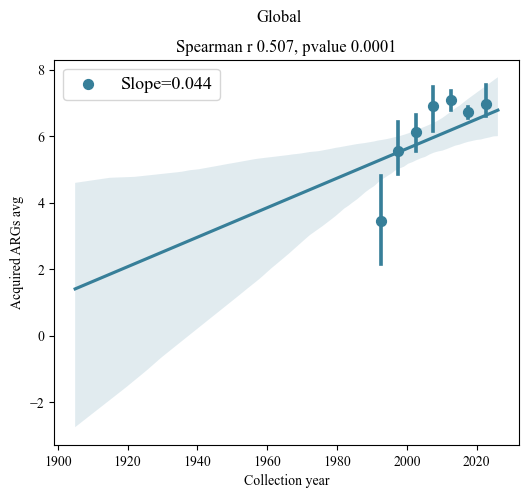

In [ ]:
#横轴为year时，都是平均ARGs。为了避免每年收集的菌株数量不同带来的影响。
df_avg = df_summary.groupby('year')['Acquired_ARGs'].mean().reset_index()
df_avg = df_avg.rename(columns={'Acquired_ARGs': 'Acquired ARGs avg','year':'Collection year'})
r, p = spearmanr(df_avg['Acquired ARGs avg'], df_avg['Collection year'], nan_policy='omit')
df_calculation = df_avg
a, b = np.polyfit(df_calculation['Collection year'], df_calculation['Acquired ARGs avg'], deg=1)
plt.figure(figsize=(6, 5))
result = sns.regplot(y='Acquired ARGs avg', x='Collection year', data=df_avg,
           x_bins=np.arange(1990, 2025, 5) + 2.5,
           line_kws={'color': (55/255, 127/255, 153/255)},
            color=(55/255, 127/255, 153/255), label=f'Slope={a:.3f}'
           )
# 59, 92, 81
plt.legend(fontsize=13)
plt.suptitle("Global")
plt.title(f"Spearman r {r:.3f}, pvalue {p:.4f}")
plt.savefig("global.png",dpi=600)